In [1]:
import numpy as np # linear algebra
import pandas as pd 
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import timedelta

from PIL import Image
from wordcloud import WordCloud, STOPWORDS
import string
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("/kaggle/input/open-data-of-the-latvian-enterprise-register/25e80bf3-f107-4ab4-89ef-251b5b9374e9_data.csv") 
df

,id,regcode,sepa,name,name_before_quotes,name_in_quotes,name_after_quotes,without_quotes,regtype,regtype_text,...,registered,terminated,closed,address,index,addressid,region,city,atvk,reregistration_term
0,1,41202013815,LV53ZZZ41202013815,"IK ""KRASTNIEKI A I""",IK,KRASTNIEKI A I,NaN,0.0,K,Komercreģistrs,...,1998-02-26T00:00:00,2014-04-10T00:00:00,L,"Dundagas nov., Kolkas pag., Kolka, ""Krastnieki""",3275.0,103045133,100015821,0.0,885162.0,NaN
1,2,40008234596,LV49ZZZ40008234596,"""House of Glory""",NaN,House of Glory,NaN,0.0,B,Biedrību un nodibinājumu reģistrs,...,2015-03-02T00:00:00,NaN,,"Rīga, Latgales iela 180 - 5",1019.0,112303082,0,100003003.0,NaN,NaN
2,3,40008048734,LV28ZZZ40008048734,"Mednieku klubs ""Atpūtas""",Mednieku klubs,Atpūtas,NaN,0.0,B,Biedrību un nodibinājumu reģistrs,...,2000-02-23T00:00:00,NaN,,"Rīga, Zemes iela 4 - 69",1082.0,115058568,0,100003003.0,10000.0,NaN
3,4,40002158072,LV09ZZZ40002158072,IK DANDIS,IK,DANDIS,NaN,1.0,K,Komercreģistrs,...,2010-11-24T00:00:00,2014-04-09T00:00:00,L,"Babītes nov., Babītes pag., Vīkuļi, ""Jaunskadiņi""",2107.0,103045920,100015725,0.0,804948.0,NaN
4,5,40002102524,LV88ZZZ40002102524,"IK ""Dīfija""",IK,Dīfija,NaN,0.0,K,Komercreģistrs,...,2004-04-02T00:00:00,2014-04-09T00:00:00,L,"Rīga, Avotu iela 17",1011.0,101858996,0,100003003.0,10000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472787,472788,740526,NaN,Avīzes Nosaukums,NaN,NaN,NaN,NaN,M,MIL reģistrs,...,2022-09-19T00:00:00,NaN,,NaN,NaN,0,0,0.0,NaN,NaN
472788,472789,740122,NaN,"""Poliklīnika""",NaN,NaN,NaN,NaN,M,MIL reģistrs,...,2011-12-15T00:00:00,NaN,,"Rīga, Grēdu iela 4A",1019.0,105177231,0,100003003.0,1000.0,NaN
472789,472790,740183,NaN,"Reformisti, PIETIEK!",NaN,NaN,NaN,NaN,M,MIL reģistrs,...,2013-02-15T00:00:00,NaN,,"Rīga, Biķernieku iela 122 k-6 -15",1079.0,117573325,0,100003003.0,1000.0,NaN
472790,472791,740235,NaN,Poļeznaja gazeta,NaN,NaN,NaN,NaN,M,MIL reģistrs,...,2013-12-16T00:00:00,NaN,,"Rīga, Valmieras iela 43-2",1009.0,113231854,0,100003003.0,1000.0,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472792 entries, 0 to 472791
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   472792 non-null  int64  
 1   regcode              472792 non-null  int64  
 2   sepa                 363109 non-null  object 
 3   name                 472790 non-null  object 
 4   name_before_quotes   427499 non-null  object 
 5   name_in_quotes       458656 non-null  object 
 6   name_after_quotes    21399 non-null   object 
 7   without_quotes       468556 non-null  float64
 8   regtype              472792 non-null  object 
 9   regtype_text         472792 non-null  object 
 10  type                 472792 non-null  object 
 11  type_text            471389 non-null  object 
 12  registered           472698 non-null  object 
 13  terminated           258096 non-null  object 
 14  closed               472792 non-null  object 
 15  address          

In [4]:
print(df.size) 

10401424


In [5]:
print(df.shape) 

(472792, 22)


In [6]:
print(f'✔️The shape of the data is: {df.shape}\n')
print(f'✔️The size of the data is: {df.size}\n')
print(f'✔️The columns in the dataset are: \n {df.columns}')

✔️The shape of the data is: (472792, 22)

✔️The size of the data is: 10401424

✔️The columns in the dataset are: 
 Index(['id', 'regcode', 'sepa', 'name', 'name_before_quotes', 'name_in_quotes',
       'name_after_quotes', 'without_quotes', 'regtype', 'regtype_text',
       'type', 'type_text', 'registered', 'terminated', 'closed', 'address',
       'index', 'addressid', 'region', 'city', 'atvk', 'reregistration_term'],
      dtype='object')


In [7]:
df.isna().sum()

id                          0
regcode                     0
sepa                   109683
name                        2
name_before_quotes      45293
name_in_quotes          14136
name_after_quotes      451393
without_quotes           4236
regtype                     0
regtype_text                0
type                        0
type_text                1403
registered                 94
terminated             214696
closed                      0
address                   533
index                   20159
addressid                   0
region                      0
city                        1
atvk                    66170
reregistration_term    472770
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
if df.duplicated().any()>0:
    print(f"✔️The number of duplicates are {df.duplicated().sum()}")
else:
    print(f'✔️There are no duplicates r in the dataset')

✔️There are no duplicates r in the dataset


In [10]:
df.describe()

,id,regcode,without_quotes,index,addressid,region,city,atvk
count,472792.000000,4.727920e+05,468556.000000,452633.00000,4.727920e+05,4.727920e+05,4.727910e+05,406622.000000
mean,236396.500000,3.922229e+10,0.106233,2359.67906,1.073524e+08,3.246498e+07,7.535698e+07,276167.549289
std,136483.438572,1.175352e+10,0.308136,1560.19857,1.144591e+07,4.683005e+07,4.309595e+07,336884.113235
min,1.000000,1.000070e+05,0.000000,101.00000,0.000000e+00,0.000000e+00,0.000000e+00,1000.000000
25%,118198.750000,4.000381e+10,0.000000,1024.00000,1.020011e+08,0.000000e+00,1.000030e+08,10000.000000
50%,236396.500000,4.010381e+10,0.000000,1084.00000,1.062520e+08,0.000000e+00,1.000030e+08,10000.000000
75%,354594.250000,4.240101e+10,0.000000,3701.00000,1.134210e+08,1.000158e+08,1.000030e+08,620201.000000
max,472792.000000,9.950000e+10,1.000000,6250.00000,1.195839e+08,1.000168e+08,1.000038e+08,989400.000000


In [11]:
reg=df['registered'].value_counts().reset_index()
reg

,registered,count
0,1992-03-31T00:00:00,383
1,1994-12-29T00:00:00,353
2,1992-03-24T00:00:00,348
3,1992-03-20T00:00:00,323
4,1992-04-14T00:00:00,311
...,...,...
9105,1999-06-06T00:00:00,1
9106,2001-02-10T00:00:00,1
9107,2024-02-25T00:00:00,1
9108,1993-01-31T00:00:00,1


In [12]:
# Convert 'registered' and 'terminated' to datetime
df['registered'] = pd.to_datetime(df['registered'])
df['terminated'] = pd.to_datetime(df['terminated'])

# Use .dt.year to extract the year from the datetime column
df = df[df['registered'].dt.year <= 2024].copy()

# Print min and max dates for 'registered' and 'terminated' columns
print("\n ☑️ Minimum and Maximum Dates:")

if not df.empty:
    min_registered = df['registered'].min()
    max_registered = df['registered'].max()
    min_terminated = df['terminated'].min()
    max_terminated = df['terminated'].max()

    print(f"  ✔️ Registered Date Range: {min_registered} to {max_registered}")
    print(f"  ✔️ Terminated Date Range: {min_terminated} to {max_terminated}")
else:
    print("⚠️ DataFrame is empty, cannot determine date range.")


 ☑️ Minimum and Maximum Dates:
  ✔️ Registered Date Range: 1990-04-17 00:00:00 to 2024-12-28 00:00:00
  ✔️ Terminated Date Range: 1991-04-19 00:00:00 to 2025-06-06 00:00:00


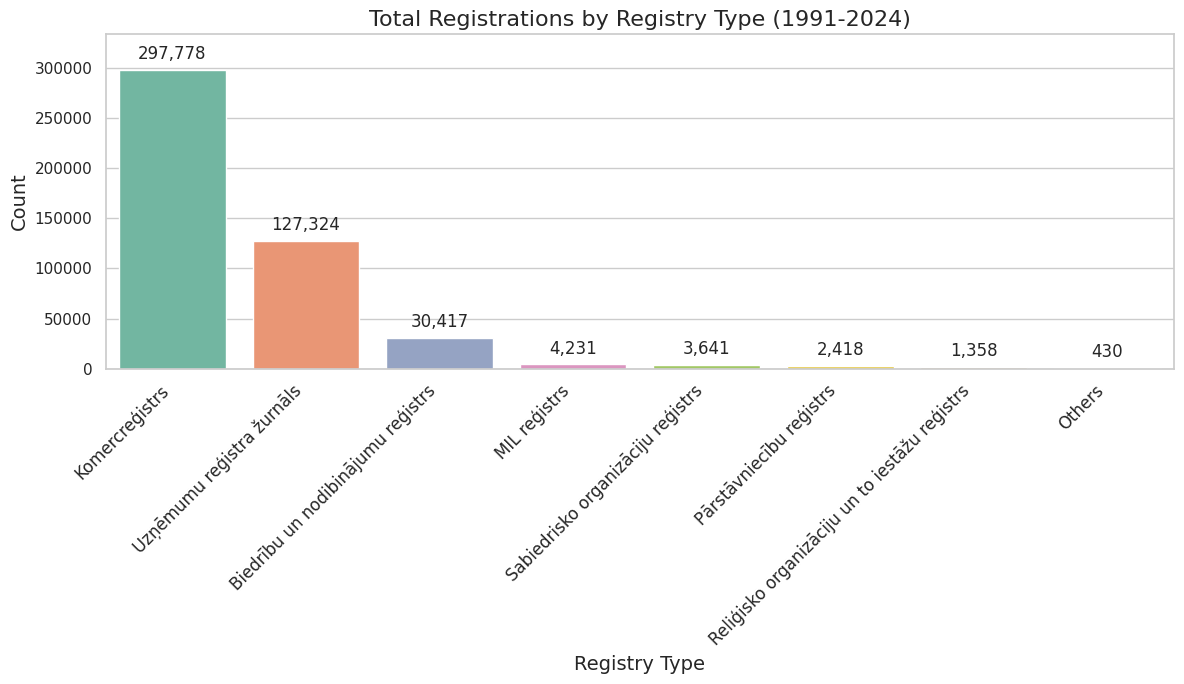

In [13]:
raw_regtype_counts = df['regtype_text'].value_counts()
threshold = 300 
major_regtypes = raw_regtype_counts[raw_regtype_counts >= threshold]
others_sum_regtypes = raw_regtype_counts[raw_regtype_counts < threshold].sum()

if others_sum_regtypes > 0:
    others_series_regtypes = pd.Series([others_sum_regtypes], index=['Others'])
    plot_counts_series_regtypes = pd.concat([major_regtypes, others_series_regtypes])
else:
    plot_counts_series_regtypes = major_regtypes

regtype_counts_df_grouped = plot_counts_series_regtypes.reset_index()
regtype_counts_df_grouped.columns = ['Registry Type', 'Count']

regtype_counts_df_grouped = regtype_counts_df_grouped.sort_values('Count', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

num_categories = len(regtype_counts_df_grouped['Registry Type'])
palette = sns.color_palette("Set2", n_colors=num_categories if num_categories > 0 else 1)

ax = sns.barplot(
    x='Registry Type',
    y='Count',
    data=regtype_counts_df_grouped,
    palette=palette,
    order=regtype_counts_df_grouped['Registry Type'].tolist()
)

ax.set_title('Total Registrations by Registry Type (1991-2024)', fontsize=16)
ax.set_xlabel('Registry Type', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)

if not regtype_counts_df_grouped.empty:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{int(height):,}",
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center',
                        va='bottom',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=12)

if not regtype_counts_df_grouped.empty:
    current_max_y = regtype_counts_df_grouped['Count'].max()
    ax.set_ylim(0, current_max_y * 1.12 if current_max_y > 0 else 10)
else:
    ax.set_ylim(0,10)

plt.tight_layout()
plt.show()

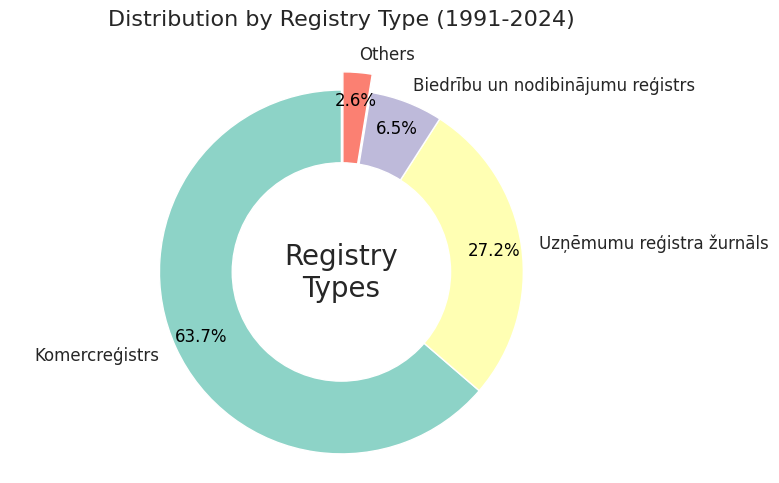

In [14]:
type_counts = df['regtype_text'].value_counts()
threshold = 5000
main_types = type_counts[type_counts >= threshold]
other_types_sum = type_counts[type_counts < threshold].sum()

if other_types_sum > 0:
    plot_data = pd.concat([main_types, pd.Series({'Others': other_types_sum})])
else:
    plot_data = main_types

num_categories = len(plot_data)
colors = sns.color_palette('Set3', num_categories)
explode = [0] * len(plot_data)
if 'Others' in plot_data.index:
    others_index = plot_data.index.get_loc('Others')
    explode[others_index] = 0.1

fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    plot_data.values,
    labels=plot_data.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white'}
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
for text in texts:
    text.set_fontsize(12)

centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal')
ax.set_title('Distribution by Registry Type (1991-2024)', fontsize=16, pad=20)
ax.text(0, 0, 'Registry\nTypes', ha='center', va='center', fontsize=20)

plt.tight_layout()
plt.show()

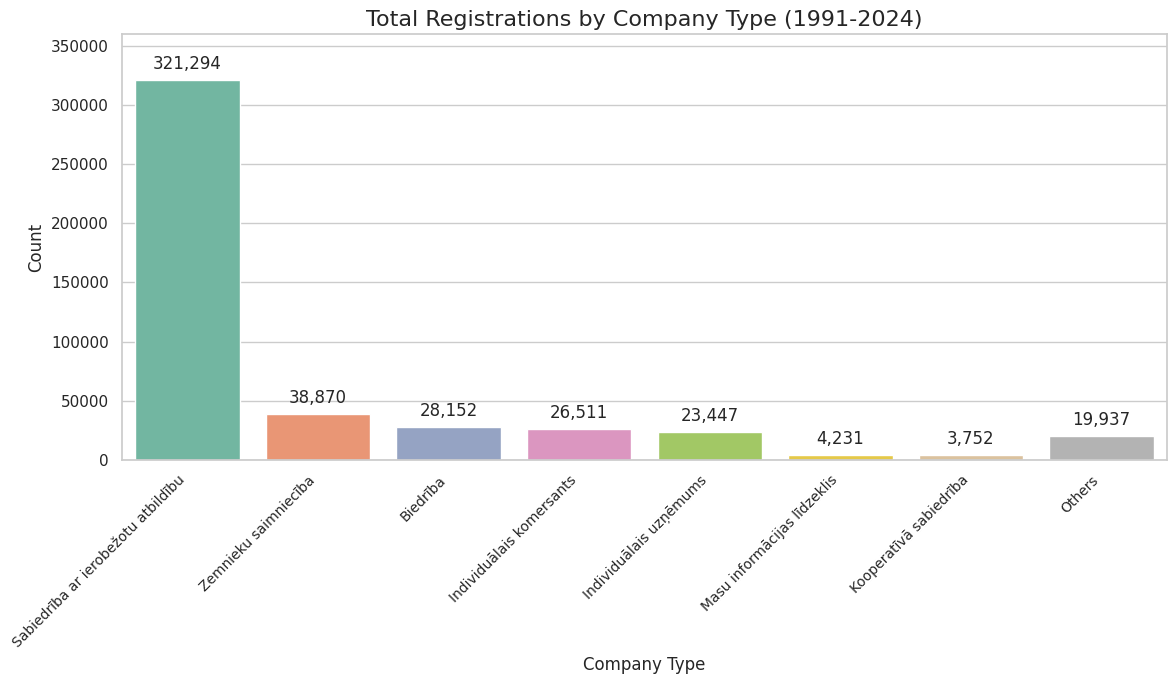

In [15]:
#Bar Plot for Company Type
type_counts = df['type_text'].value_counts()

threshold = 3000

major_types = type_counts[type_counts >= threshold]
others_sum = type_counts[type_counts < threshold].sum()

if others_sum > 0:
    others_series = pd.Series([others_sum], index=['Others'])
    plot_counts_series = pd.concat([major_types, others_series])
else:
    plot_counts_series = major_types

type_counts_df_grouped = plot_counts_series.reset_index()
type_counts_df_grouped.columns = ['Entity Type', 'Count']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

num_categories = len(type_counts_df_grouped['Entity Type'])
palette = sns.color_palette("Set2", n_colors=num_categories if num_categories > 0 else 1)

ax = sns.barplot(
    x='Entity Type',
    y='Count',
    data=type_counts_df_grouped,
    palette=palette,
)

ax.set_title('Total Registrations by Company Type (1991-2024)', fontsize=16)
ax.set_xlabel('Company Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)

if not type_counts_df_grouped.empty:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{int(height):,}",
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center',
                        va='bottom',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=12)

if not type_counts_df_grouped.empty:
    current_max_y = type_counts_df_grouped['Count'].max()
    ax.set_ylim(0, current_max_y * 1.12 if current_max_y > 0 else 10)
else:
    ax.set_ylim(0,10)

plt.tight_layout()
plt.show()

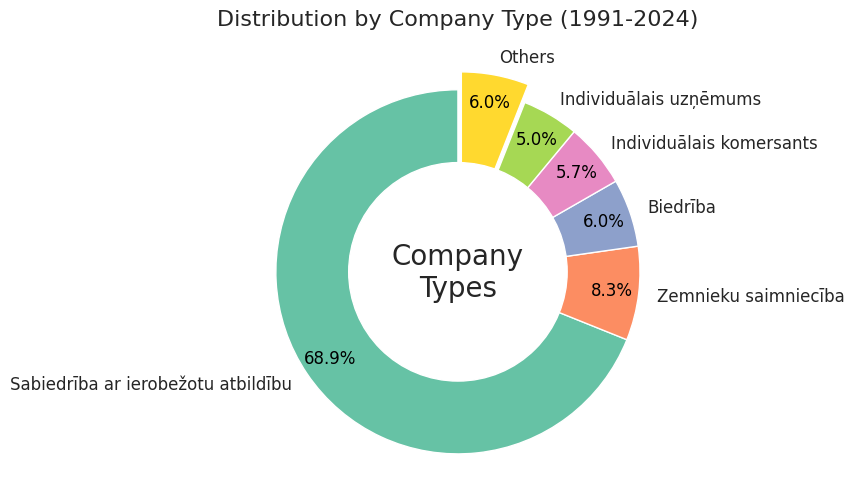

In [16]:
type_counts = df['type_text'].value_counts()
threshold = 5000
main_types = type_counts[type_counts >= threshold]
other_types_sum = type_counts[type_counts < threshold].sum()

if other_types_sum > 0:
    plot_data = pd.concat([main_types, pd.Series({'Others': other_types_sum})])
else:
    plot_data = main_types

num_categories = len(plot_data)
colors = sns.color_palette('Set2', num_categories)
explode = [0] * len(plot_data)
if 'Others' in plot_data.index:
    others_index = plot_data.index.get_loc('Others')
    explode[others_index] = 0.1

fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    plot_data.values,
    labels=plot_data.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white'}
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
for text in texts:
    text.set_fontsize(12)

centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal')
ax.set_title('Distribution by Company Type (1991-2024)', fontsize=16, pad=20)
ax.text(0, 0, 'Company\nTypes', ha='center', va='center', fontsize=20)
plt.tight_layout()
plt.show()


Major types (>= 5000 registrations): ['Komercreģistrs', 'Uzņēmumu reģistra žurnāls', 'Biedrību un nodibinājumu reģistrs']


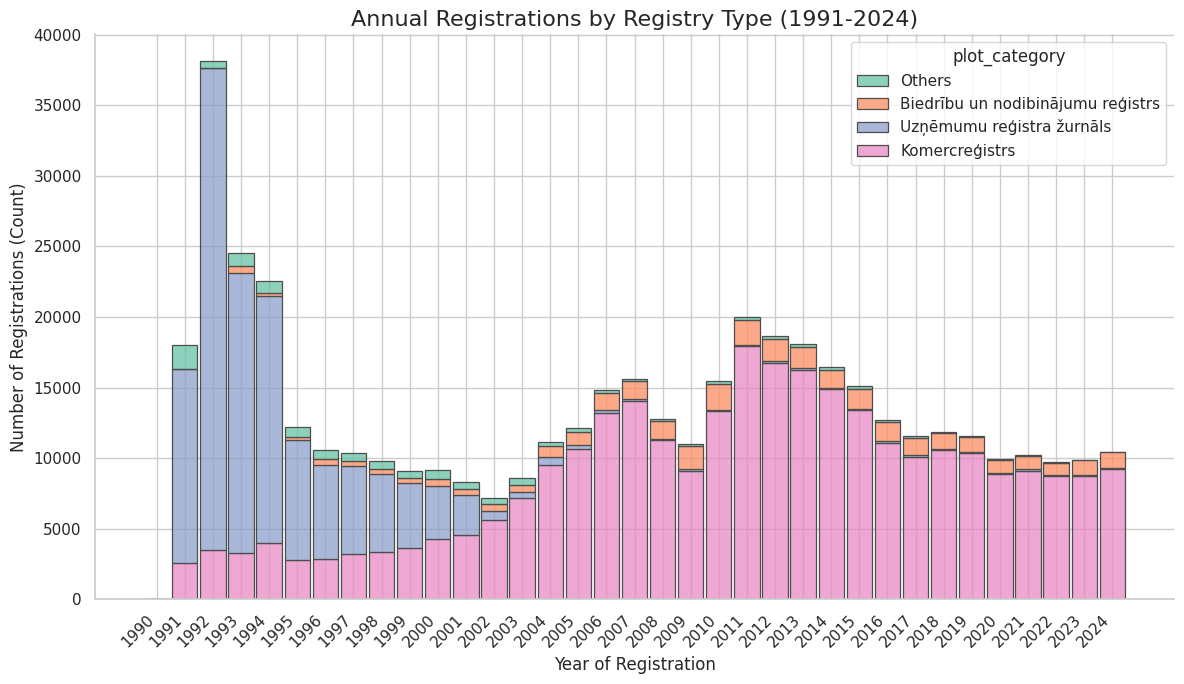

In [17]:
# Stacked histogram plot
sns.set_theme(style="whitegrid")

df_data = df.copy()
df_data['registered'] = pd.to_datetime(df_data['registered'], errors='coerce')
df_data.dropna(subset=['registered'], inplace=True)
df_data['year'] = df_data['registered'].dt.year.astype(int)
type_total_counts = df_data['regtype_text'].value_counts()

threshold = 5000
major_types_list = type_total_counts[type_total_counts >= threshold].index.tolist()
print(f"\nMajor types (>= {threshold} registrations): {major_types_list}")

df_data['plot_category'] = df_data['regtype_text'].apply(
    lambda x: x if x in major_types_list else 'Others'
)

plot_categories_unique = df_data['plot_category'].unique()
plot_category_counts = type_total_counts.loc[type_total_counts.index.isin(major_types_list)].copy()
if 'Others' in plot_categories_unique:
    others_sum = type_total_counts[~type_total_counts.index.isin(major_types_list)].sum()
    if others_sum > 0:
        plot_category_counts['Others'] = others_sum
        
hue_category_order = plot_category_counts.sort_values(ascending=True).index.tolist()

f, ax = plt.subplots(figsize=(12, 7))
sns.despine(f)
sns.histplot(
    data=df_data,
    x="year",
    hue="plot_category",
    hue_order=hue_category_order,
    multiple="stack",
    palette="Set2",
    edgecolor=".3",
    linewidth=.9,
    discrete=True,
    shrink=0.9
)

ax.set_xlabel("Year of Registration", fontsize=12)
ax.set_ylabel("Number of Registrations (Count)", fontsize=12)
ax.set_title("Annual Registrations by Registry Type (1991-2024)", fontsize=16)

unique_years = sorted(df_data['year'].unique())
if unique_years:
    ax.set_xticks(unique_years)
    ax.set_xticklabels([str(int(yr)) for yr in unique_years], rotation=45, ha='right')

plt.tight_layout()
plt.show()

Found 13404 potential 1998 crisis victims with valid lifespan.
Found 20104 potential 2008 crisis victims with valid lifespan.


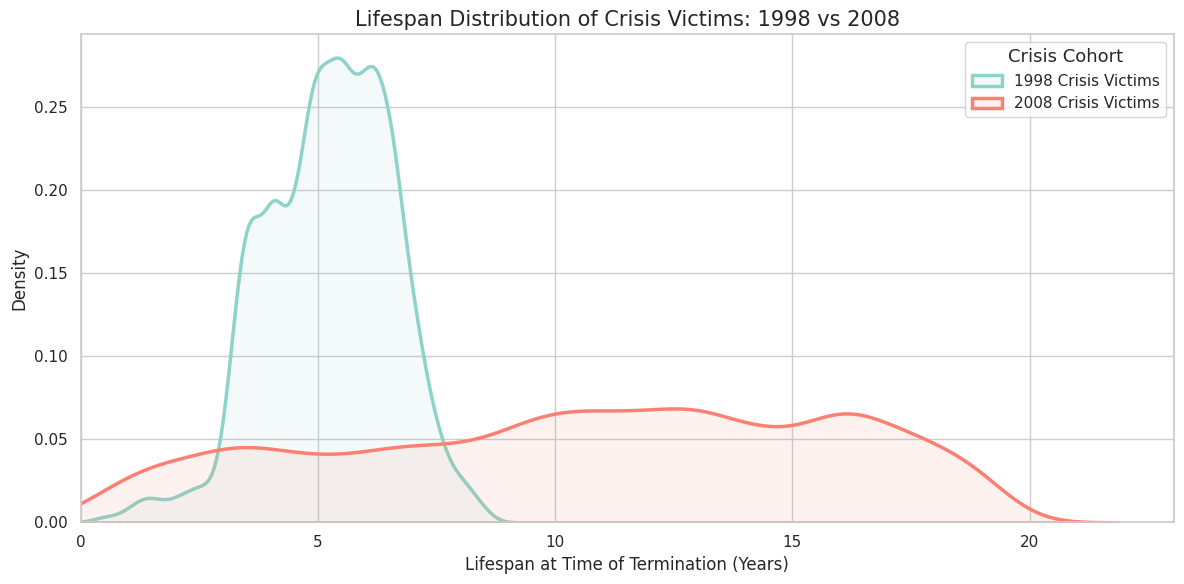

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Data Preparation ---
# (This section is assumed to have been run with your df_data)
# Ensure date columns are datetime objects
df['registered'] = pd.to_datetime(df['registered'], errors='coerce')
df['terminated'] = pd.to_datetime(df['terminated'], errors='coerce')

crisis_1998_start = '1998-01-01'
crisis_1998_end = '1999-12-31'

# The GFC impact was felt most in terminations from 2008 onwards
crisis_2008_start = '2008-01-01'
crisis_2008_end = '2010-12-31'

victims_1998_df = df[
    (df['terminated'] >= crisis_1998_start) &
    (df['terminated'] <= crisis_1998_end)
].copy()

victims_2008_df = df[
    (df['terminated'] >= crisis_2008_start) &
    (df['terminated'] <= crisis_2008_end)
].copy()

# Ensure we only calculate lifespans where both dates are valid
victims_1998_df.dropna(subset=['registered', 'terminated'], inplace=True)
victims_2008_df.dropna(subset=['registered', 'terminated'], inplace=True)

victims_1998_df['lifespan_days'] = (victims_1998_df['terminated'] - victims_1998_df['registered']).dt.days
victims_2008_df['lifespan_days'] = (victims_2008_df['terminated'] - victims_2008_df['registered']).dt.days

victims_1998 = victims_1998_df['lifespan_days'] / 365.25 
victims_2008 = victims_2008_df['lifespan_days'] / 365.25

print(f"Found {len(victims_1998.dropna())} potential 1998 crisis victims with valid lifespan.")
print(f"Found {len(victims_2008.dropna())} potential 2008 crisis victims with valid lifespan.")

# --- 2. Create the Plot with "Set3" Colors ---
fig, ax = plt.subplots(figsize=(12, 6)) # Adjusted size slightly

# Define the color palette from Seaborn
set3_palette = sns.color_palette("Set3", 5)

# Plot for 1998 Crisis Victims
if not victims_1998.dropna().empty:
    sns.kdeplot(
        victims_1998.dropna(),
        label='1998 Crisis Victims',
        ax=ax,
        linewidth=2.5,
        color=set3_palette[0], # Using the first color from Set3
        fill=True, alpha=0.1   # Added fill for better visibility
    )
else:
    print("⚠️ No data for 1998 crisis victims to plot KDE.")

# Plot for 2008 Crisis Victims
if not victims_2008.dropna().empty:
    sns.kdeplot(
        victims_2008.dropna(),
        label='2008 Crisis Victims',
        ax=ax,
        linewidth=2.5,
        color=set3_palette[3], # Using the second color from Set3
        fill=True, alpha=0.1
    )
else:
    print("⚠️ No data for 2008 crisis victims to plot KDE.")

# --- 3. Customize the Plot ---
ax.set_title('Lifespan Distribution of Crisis Victims: 1998 vs 2008', fontsize=15)
ax.set_xlabel('Lifespan at Time of Termination (Years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(0) # Ensure x-axis starts at 0

if not victims_1998.dropna().empty or not victims_2008.dropna().empty:
    ax.legend(title='Crisis Cohort', title_fontsize='13', fontsize='11', frameon=True)
else:
    print("⚠️ No data plotted, legend will be empty.")

plt.tight_layout()
plt.show()


☑️ --- Lifespan Analysis Report ---
✔️ Total companies with positive lifespans analyzed: 257965

✔️ Summary statistics for company lifespan (in years):
count    257965.00
mean          9.65
std           6.38
min           0.00
25%           4.89
50%           8.19
75%          12.90
max          34.26
Name: lifespan_years, dtype: float64
✔️ Median Lifespan: 8.19 years
-------------------------------------



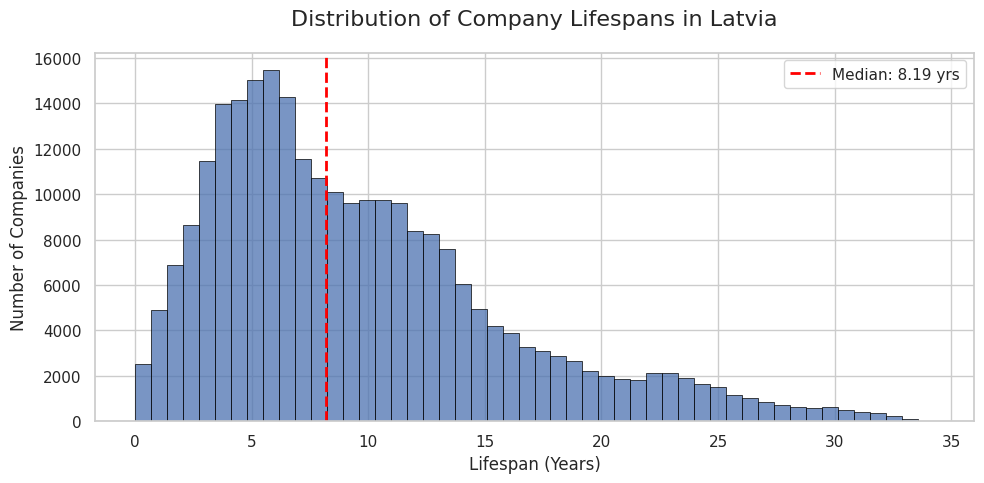

In [19]:
# Lifespan histogram
sns.set_theme(style="whitegrid") 

df_analysis = df.copy()
df_analysis['registered'] = pd.to_datetime(df_analysis['registered'], errors='coerce')
df_analysis['terminated'] = pd.to_datetime(df_analysis['terminated'], errors='coerce')
df_terminated_updated = df_analysis.dropna(subset=['terminated']).copy()
df_terminated_updated.dropna(subset=['registered', 'terminated'], inplace=True)
df_terminated_updated['lifespan_years'] = \
    (df_terminated_updated['terminated'] - df_terminated_updated['registered']).dt.days / 365.25
df_terminated_updated.dropna(subset=['lifespan_years'], inplace=True)
df_terminated_updated = df_terminated_updated[df_terminated_updated['lifespan_years'] > 0]

median_lifespan_value = np.nan
if not df_terminated_updated.empty:
    print("\n☑️ --- Lifespan Analysis Report ---")
    print(f"✔️ Total companies with positive lifespans analyzed: {len(df_terminated_updated)}")
    print("\n✔️ Summary statistics for company lifespan (in years):")
    description = df_terminated_updated['lifespan_years'].describe().round(2)
    print(description)
    median_lifespan_value = description['50%'] # Get median from describe output
    print(f"✔️ Median Lifespan: {median_lifespan_value:.2f} years")
    print("-------------------------------------\n")
else:
    print("\n⚠️ No valid lifespan data available for numerical report after filtering.")

fig, ax = plt.subplots(figsize=(10, 5))
if not df_terminated_updated.empty:
    sns.histplot(
        data=df_terminated_updated,
        x='lifespan_years',
        bins=50,
        ax=ax,
        palette="Set2",
        edgecolor='black',
        linewidth=0.5
    )

    if pd.notna(median_lifespan_value):
        ax.axvline(
            median_lifespan_value,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Median: {median_lifespan_value:.2f} yrs'
        )

    ax.set_title('Distribution of Company Lifespans in Latvia', fontsize=16, pad=20)
    ax.set_xlabel('Lifespan (Years)', fontsize=12)
    ax.set_ylabel('Number of Companies', fontsize=12)
    if pd.notna(median_lifespan_value):
        ax.legend()
else:
    ax.set_title('Distribution of Company Lifespans in Latvia', fontsize=16, pad=20)
    ax.set_xlabel('Lifespan (Years)', fontsize=12)
    ax.set_ylabel('Number of Companies', fontsize=12)
    ax.text(0.5, 0.5, "No lifespan data available to plot.",
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=12)
    print("⚠️ No valid lifespan data available to plot histogram.")
plt.tight_layout()
plt.show()


✔️ Selected top entity types from 'type' (count >= 1000): ['SIA', 'ZEM', 'IK', 'IND', 'BDR', 'PAR', 'KB', 'SAB', 'FIL', 'AS', 'VU', 'PSV']
✔️ Statistical summary for entity types from 'type' with at least 1000 terminated companies:

         count   mean   std   min    25%    50%    75%    max
type                                                         
ZEM    15267.0  17.48  7.80  0.03  11.21  18.32  23.52  33.76
AS      1633.0  12.12  6.42  0.04   7.44  11.77  15.13  33.87
IND    13407.0  13.15  8.34  0.00   6.35  11.62  19.91  34.26
SAB     2238.0   9.69  4.65  0.17   6.12   9.06  13.02  25.35
KB      2318.0  11.38  7.98  0.04   6.30   8.84  15.15  32.98
BDR     2875.0   9.81  5.96  0.35   5.09   8.77  13.38  32.82
FIL     1910.0   9.19  5.77  0.02   4.90   8.21  12.62  29.88
SIA   192422.0   9.01  5.58  0.00   4.83   7.72  12.06  34.21
PSV     1109.0   7.65  4.21  0.01   4.04   7.19  10.60  23.61
PAR     2350.0   7.64  4.88  0.03   4.20   6.72  10.58  29.52
VU      1152.0   6.78 

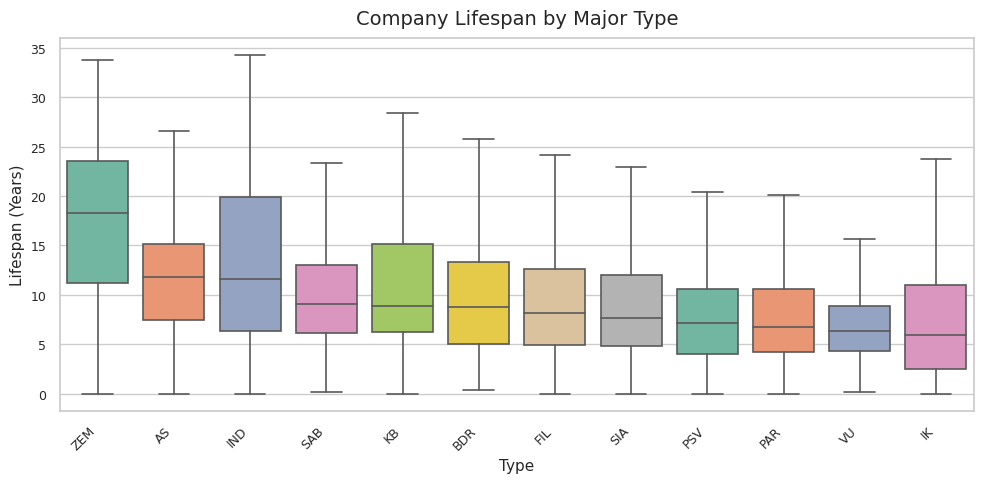

In [20]:
# Lifespan by Major Entity Type box plot
sns.set_theme(style="whitegrid")

df_data_copy = df.copy()
df_data_copy['registered'] = pd.to_datetime(df_data_copy['registered'], errors='coerce')
df_data_copy['terminated'] = pd.to_datetime(df_data_copy['terminated'], errors='coerce')
df_terminated_updated = df_data_copy.dropna(subset=['terminated']).copy()
df_terminated_updated.dropna(subset=['registered', 'terminated'], inplace=True)
df_terminated_updated['lifespan_years'] = \
    (df_terminated_updated['terminated'] - df_terminated_updated['registered']).dt.days / 365.25
df_terminated_updated.dropna(subset=['lifespan_years'], inplace=True)
df_terminated_updated = df_terminated_updated[df_terminated_updated['lifespan_years'] > 0]

entity_type_column_for_boxplot = 'type'

if entity_type_column_for_boxplot in df_terminated_updated.columns:
    df_terminated_updated[entity_type_column_for_boxplot] = df_terminated_updated[entity_type_column_for_boxplot].astype(str)
    df_terminated_updated[entity_type_column_for_boxplot] = df_terminated_updated[entity_type_column_for_boxplot].str.strip()
    df_terminated_updated[entity_type_column_for_boxplot].replace('', 'Unknown', inplace=True)
else:
    print(f"⚠️ Warning: Column '{entity_type_column_for_boxplot}' not found in df_terminated_updated! Please check your DataFrame.")

min_count_for_plot = 1000
type_counts_terminated = df_terminated_updated[entity_type_column_for_boxplot].value_counts()
top_types = type_counts_terminated[type_counts_terminated >= min_count_for_plot].index.tolist()
df_plot_box = df_terminated_updated[df_terminated_updated[entity_type_column_for_boxplot].isin(top_types)].copy()

print(f"\n✔️ Selected top entity types from '{entity_type_column_for_boxplot}' (count >= {min_count_for_plot}): {top_types}")

print(f"✔️ Statistical summary for entity types from '{entity_type_column_for_boxplot}' with at least {min_count_for_plot} terminated companies:\n")

if df_plot_box.empty:
    print(f"No entity types from '{entity_type_column_for_boxplot}' meet the criteria for the report.")
else:
    lifespan_by_type_report = df_plot_box.groupby(entity_type_column_for_boxplot)['lifespan_years'].describe().round(2)
    ordered_types_report = lifespan_by_type_report.loc[
        lifespan_by_type_report['50%'].sort_values(ascending=False).index
    ]
    print(ordered_types_report.to_string())
print("-------------------------------------------------------------\n")

if df_plot_box.empty:
    print(f"Cannot generate plot as no entity types from '{entity_type_column_for_boxplot}' meet the criteria.")
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.text(0.5, 0.5, "No data to display for box plot.",
            horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    ax.set_title(f'Company Lifespan by Major {entity_type_column_for_boxplot.replace("_"," ").title()}', fontsize=14)
    plt.show()
else:
    median_lifespans = df_plot_box.groupby(entity_type_column_for_boxplot)['lifespan_years'].median()
    ordered_types_for_plot = median_lifespans.sort_values(ascending=False).index.tolist()

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(
        data=df_plot_box,
        x=entity_type_column_for_boxplot,
        y='lifespan_years',
        order=ordered_types_for_plot,
        palette="Set2",
        showfliers=False,
        ax=ax,
        linewidth=1.2
    )

    title_text = f'Company Lifespan by Major {entity_type_column_for_boxplot.replace("_"," ").title()}'
    ax.set_title(title_text, fontsize=14, pad=10)
    ax.set_xlabel(entity_type_column_for_boxplot.replace("_"," ").title(), fontsize=11)
    ax.set_ylabel('Lifespan (Years)', fontsize=11)

    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

Analyzing years from 1990 to 2024...


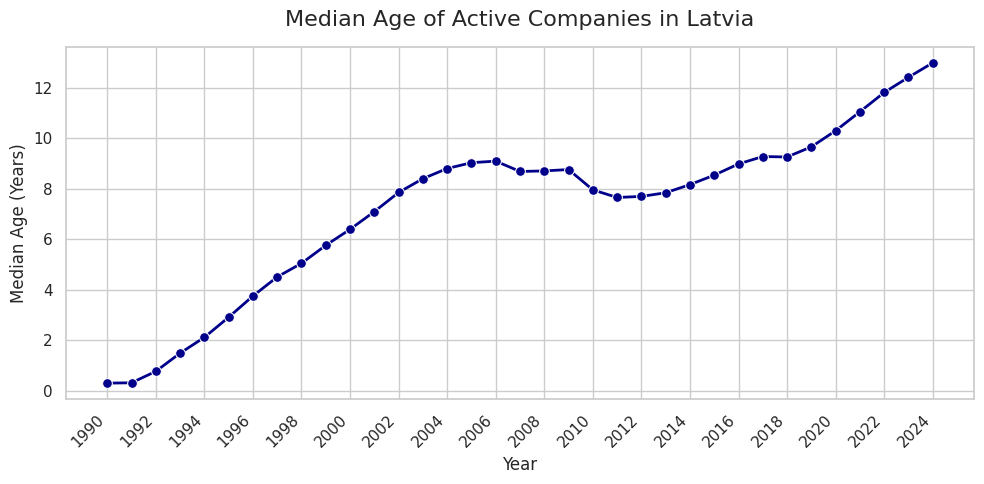

In [21]:
# Median Age of Active Companies in Latvia line plot
sns.set_theme(style="whitegrid")

df_analysis_copy = df.copy()
df_analysis_copy['registered'] = pd.to_datetime(df_analysis_copy['registered'], errors='coerce')
df_analysis_copy['terminated'] = pd.to_datetime(df_analysis_copy['terminated'], errors='coerce')
df_median_age_analysis = df_analysis_copy.dropna(subset=['registered']).copy()

if df_median_age_analysis.empty:
    print("No data available after initial preparation (df_median_age_analysis is empty). Cannot proceed.")
    age_df = pd.DataFrame(columns=['year', 'median_age'])
else:
    min_year_series = df_median_age_analysis['registered'].dt.year
    if min_year_series.empty:
        print("No 'registered' dates found to determine year range. Cannot proceed.")
        age_df = pd.DataFrame(columns=['year', 'median_age'])
    else:
        min_year = min_year_series.min()
        max_year = min_year_series.max()
        if pd.isna(min_year) or pd.isna(max_year):
            print("Could not determine valid year range from 'registered' dates. Cannot proceed.")
            age_df = pd.DataFrame(columns=['year', 'median_age'])
        else:
            years_to_analyze = range(int(min_year), int(max_year) + 1)
            median_ages = []
            print(f"Analyzing years from {int(min_year)} to {int(max_year)}...")
            for year_val in years_to_analyze:
                current_date_loop = pd.to_datetime(f"{year_val}-12-31")
                active_df_loop = df_median_age_analysis[
                    (df_median_age_analysis['registered'] <= current_date_loop) &
                    (
                        (df_median_age_analysis['terminated'].isna()) |
                        (df_median_age_analysis['terminated'] > current_date_loop)
                    )
                ]
                if active_df_loop.empty:
                    median_ages.append({'year': year_val, 'median_age': float('nan')})
                    continue
                ages = (current_date_loop - active_df_loop['registered']).dt.days / 365.25
                ages = ages[ages > 0]
                if ages.empty:
                    median_ages.append({'year': year_val, 'median_age': float('nan')})
                else:
                    median_age = ages.median()
                    median_ages.append({'year': year_val, 'median_age': median_age})
            age_df = pd.DataFrame(median_ages)
            age_df.dropna(subset=['median_age'], inplace=True) # Remove years where median couldn't be calculated

fig, ax = plt.subplots(figsize=(10, 5))
if not age_df.empty:
    sns.lineplot(
        data=age_df,
        x='year',
        y='median_age',
        ax=ax,
        color='darkblue',
        marker='o',
        markersize=7,
        linewidth=2
    )

    ax.set_title('Median Age of Active Companies in Latvia', fontsize=16, pad=15)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Median Age (Years)', fontsize=12)

    if len(age_df['year']) > 1:
        start_yr = int(age_df['year'].min())
        end_yr = int(age_df['year'].max())
        tick_step = max(1, (end_yr - start_yr) // 15)
        ax.set_xticks(range(start_yr, end_yr + 1, tick_step))
        plt.xticks(rotation=45, ha='right')

else:
    # Handle case where there's no data to plot
    ax.set_title('Median Age of Active Companies in Latvia', fontsize=16, pad=15)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Median Age (Years)', fontsize=12)
    ax.text(0.5, 0.5, "No data available to generate the plot.",
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=12)
    print("⚠️ No data available to generate the plot (age_df is empty).")

plt.tight_layout()
plt.show()

Analyzing cohort years from 1990 to 2024...


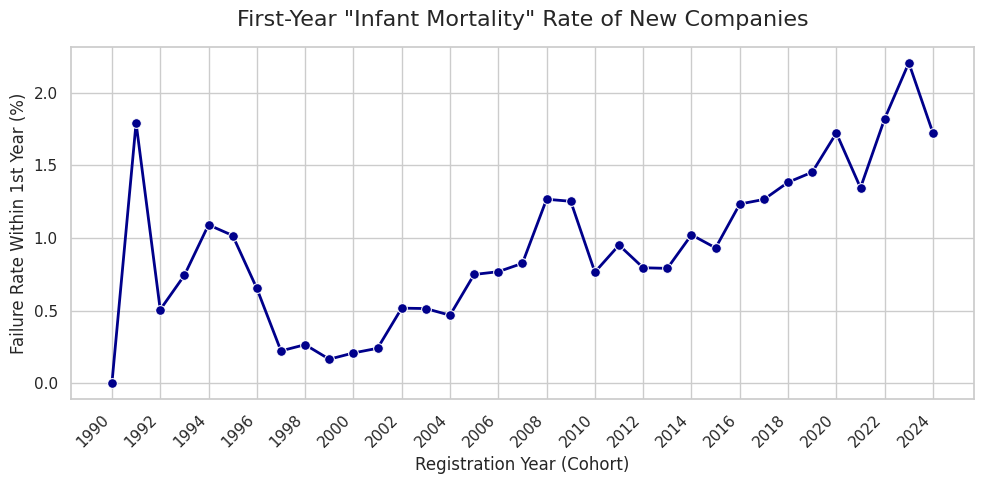

In [22]:
# Infant Mortality Rate plot
sns.set_theme(style="whitegrid")

df_analysis_copy = df.copy() # Work on a copy
df_analysis_copy['registered'] = pd.to_datetime(df_analysis_copy['registered'], errors='coerce')
df_analysis_copy['terminated'] = pd.to_datetime(df_analysis_copy['terminated'], errors='coerce')
df_mortality_analysis = df_analysis_copy.dropna(subset=['registered']).copy()

if df_mortality_analysis.empty or df_mortality_analysis['registered'].dt.year.empty:
    print("⚠️ No registration data available to determine cohort years. Cannot proceed.")
    mortality_df = pd.DataFrame(columns=['year', 'failure_rate'])
else:
    cohort_years = sorted(df_mortality_analysis['registered'].dt.year.unique())
    mortality_data = []
    print(f"Analyzing cohort years from {min(cohort_years)} to {max(cohort_years)}...")

    for year in cohort_years:
        cohort_df = df_mortality_analysis[df_mortality_analysis['registered'].dt.year == year]
        total_in_cohort = len(cohort_df)

        if total_in_cohort == 0:
            mortality_data.append({'year': int(year), 'failure_rate': float('nan')})
            continue
        one_year_later_delta = timedelta(days=365)
        valid_lifespan_cohort_df = cohort_df.dropna(subset=['registered', 'terminated'])
        failed_in_first_year = valid_lifespan_cohort_df[
            (valid_lifespan_cohort_df['terminated'] - valid_lifespan_cohort_df['registered']) <= one_year_later_delta
        ]
        failure_count = len(failed_in_first_year)
        failure_rate = (failure_count / total_in_cohort) * 100 if total_in_cohort > 0 else 0
        mortality_data.append({'year': int(year), 'failure_rate': failure_rate})

    mortality_df = pd.DataFrame(mortality_data)
    mortality_df.dropna(subset=['failure_rate'], inplace=True)

fig, ax = plt.subplots(figsize=(10, 5))
if not mortality_df.empty:
    sns.lineplot(
        data=mortality_df,
        x='year',
        y='failure_rate',
        ax=ax,
        color='darkblue',
        marker='o',
        markersize=7,
        linewidth=2
    )

    ax.set_title('First-Year "Infant Mortality" Rate of New Companies', fontsize=16, pad=15)
    ax.set_xlabel('Registration Year (Cohort)', fontsize=12)
    ax.set_ylabel('Failure Rate Within 1st Year (%)', fontsize=12)

    if len(mortality_df['year']) > 1:
        start_yr = int(mortality_df['year'].min())
        end_yr = int(mortality_df['year'].max())
        num_years_total = end_yr - start_yr + 1

        tick_step = 1
        if num_years_total > 20:
            tick_step = max(1, num_years_total // 15)
        elif num_years_total > 10:
            tick_step = 2

        ax.set_xticks(np.arange(start_yr, end_yr + 1, tick_step).astype(int))
        plt.xticks(rotation=45, ha='right')
    elif len(mortality_df['year']) == 1:
        ax.set_xticks([int(mortality_df['year'].iloc[0])])

else:
    ax.set_title('First-Year "Infant Mortality" Rate of New Companies', fontsize=16, pad=15)
    ax.set_xlabel('Registration Year (Cohort)', fontsize=12)
    ax.set_ylabel('Failure Rate Within 1st Year (%)', fontsize=12)
    ax.text(0.5, 0.5, "No data available to generate the plot.",
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=12)
    print("⚠️ No data available to generate the plot (mortality_df is empty).")

plt.tight_layout()
plt.show()

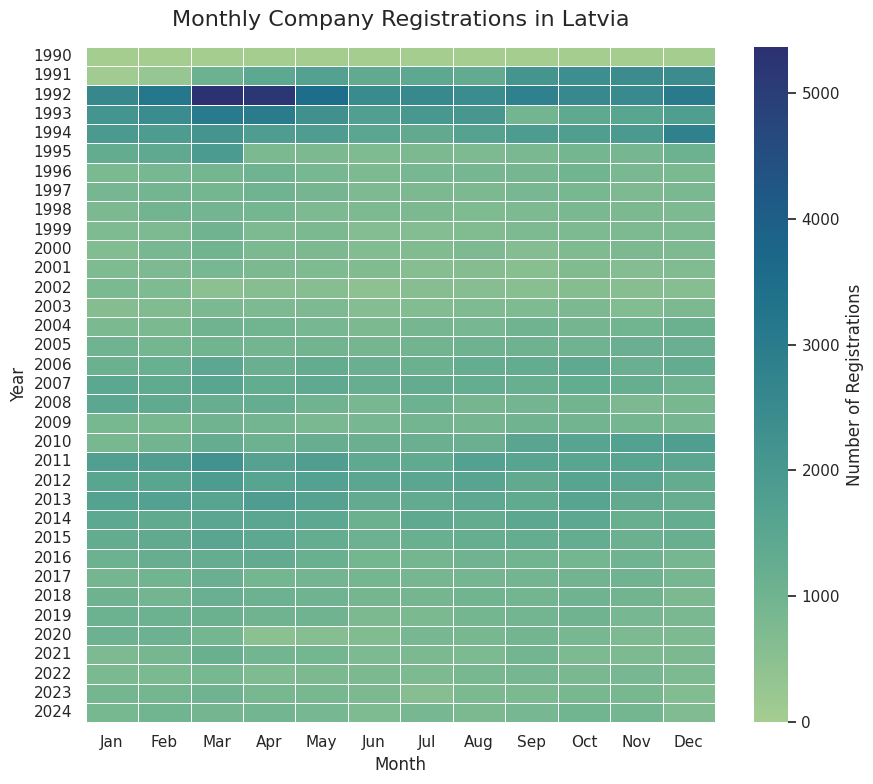

In [23]:
# Monthly Company Registrations Heatmap
sns.set_theme(style="whitegrid")

df_analysis_copy = df.copy() # Work on a copy
df_analysis_copy['registered'] = pd.to_datetime(df_analysis_copy['registered'], errors='coerce')
df_heatmap_analysis = df_analysis_copy.dropna(subset=['registered']).copy()

if df_heatmap_analysis.empty:
    print("⚠️ No valid registration data to create heatmap.")
    heatmap_df = pd.DataFrame() # Ensure heatmap_df is defined
else:
    heatmap_df = df_heatmap_analysis.groupby(
        [df_heatmap_analysis['registered'].dt.year.rename('year'),
         df_heatmap_analysis['registered'].dt.month.rename('month')]
    ).size().unstack(fill_value=0)
    heatmap_df = heatmap_df.reindex(columns=range(1, 13), fill_value=0)
    heatmap_df.sort_index(ascending=True, inplace=True)

month_names = []
if not heatmap_df.empty:
    month_names = [calendar.month_abbr[i] for i in range(1, 13)]

fig, ax = plt.subplots(figsize=(9, 8))
if not heatmap_df.empty:
    sns.heatmap(
        heatmap_df,
        ax=ax,
        annot=False,
        fmt="d",
        cmap='crest',
        linewidths=.5,
        xticklabels=month_names,
        cbar_kws={'label': 'Number of Registrations'}
    )

    ax.set_title('Monthly Company Registrations in Latvia', fontsize=16, pad=15)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Year', fontsize=12)
    plt.yticks(rotation=0)

else:
    ax.set_title('Monthly Company Registrations in Latvia', fontsize=16, pad=15)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Year', fontsize=12)
    ax.text(0.5, 0.5, "No data available to generate the heatmap.",
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=12)
    print("⚠️ No data available to generate the heatmap (heatmap_df is empty).")

plt.tight_layout()
plt.show()

,Total Registrations,Percentage
reg_day_of_week,,
Monday,88346,18.89
Tuesday,97735,20.90
Wednesday,90284,19.31
Thursday,97770,20.91
Friday,88828,19.00
Saturday,4294,0.92
Sunday,340,0.07


------------------------------------------



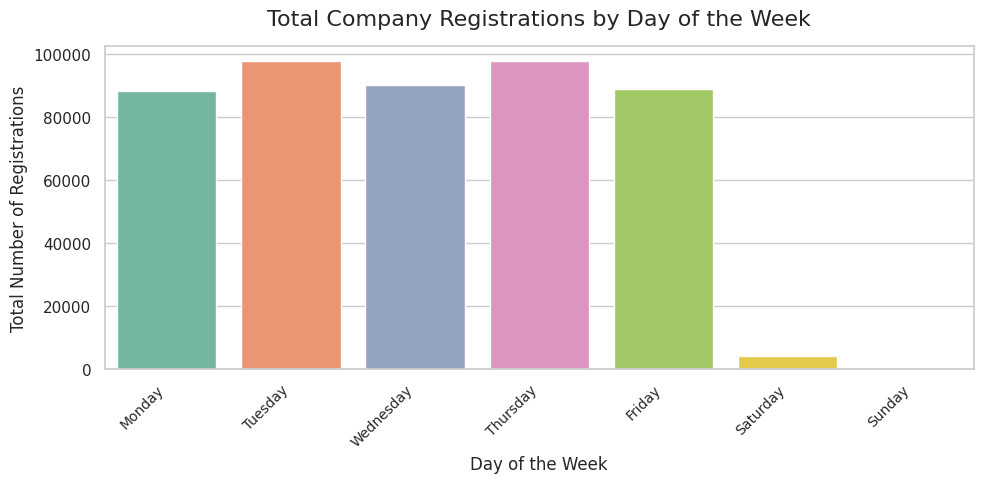

In [24]:
# Company Registrations by Day of the Week Bar Plot and report
sns.set_theme(style="whitegrid")

df_analysis_copy = df.copy()
df_analysis_copy['registered'] = pd.to_datetime(df_analysis_copy['registered'], errors='coerce')
df_day_analysis = df_analysis_copy.dropna(subset=['registered']).copy()

if not df_day_analysis.empty:
    df_day_analysis['reg_day_of_week'] = df_day_analysis['registered'].dt.day_name()
else:
    df_day_analysis['reg_day_of_week'] = pd.Series(dtype='object')

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

if not df_day_analysis.empty and not df_day_analysis['reg_day_of_week'].empty:
    day_counts = df_day_analysis['reg_day_of_week'].value_counts()
    day_percentages = df_day_analysis['reg_day_of_week'].value_counts(normalize=True) * 100
    day_report_df = pd.DataFrame({
        'Total Registrations': day_counts,
        'Percentage': day_percentages.round(2)
    }).reindex(day_order).fillna(0)
else:
    day_report_df = pd.DataFrame(columns=['Total Registrations', 'Percentage'], index=day_order).fillna(0)
try:
    display(day_report_df)
except NameError:
    print(day_report_df.to_string())
print("------------------------------------------\n")

fig, ax = plt.subplots(figsize=(10, 5))
if not day_report_df.empty:
    sns.barplot(
        x=day_report_df.index,
        y='Total Registrations',
        data=day_report_df,
        ax=ax,
        palette="Set2",
        order=day_order
    )

    ax.set_title('Total Company Registrations by Day of the Week', fontsize=16, pad=15)
    ax.set_xlabel('Day of the Week', fontsize=12)
    ax.set_ylabel('Total Number of Registrations', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)

else:
    ax.set_title('Total Company Registrations by Day of the Week', fontsize=16, pad=15)
    ax.set_xlabel('Day of the Week', fontsize=12)
    ax.set_ylabel('Total Number of Registrations', fontsize=12)
    ax.text(0.5, 0.5, "No data available to generate the plot.",
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=12)
    print("⚠️ No data available to generate the plot (day_report_df is empty).")

plt.tight_layout()
plt.show()

In [25]:
sns.set_theme(style="whitegrid")

current_date = pd.to_datetime('2024-12-31')

df_data_copy = df.copy()
df_data_copy['registered'] = pd.to_datetime(df_data_copy['registered'], errors='coerce')
df_data_copy['terminated'] = pd.to_datetime(df_data_copy['terminated'], errors='coerce')
df_active = df_data_copy[df_data_copy['terminated'].isna()].copy()
df_active.dropna(subset=['registered'], inplace=True)
if not df_active.empty:
    df_active['age'] = (current_date - df_active['registered']).dt.days / 365.25
else:
    df_active['age'] = pd.Series(dtype='float64')

entity_type_text_filter = 'Sabiedrība ar ierobežotu atbildību'
entity_type_display_name = 'SIA'
type_specific_df = df_active[df_active['type_text'] == entity_type_text_filter]

if type_specific_df.empty:
    top_20_df = pd.DataFrame(columns=['name', 'age', 'registered']) # Empty df for report
else:
    top_20_df = type_specific_df.sort_values('age', ascending=False).head(20)

if not top_20_df.empty:
    report_table_df = top_20_df[['name', 'age', 'registered']].copy()
    report_table_df.rename(columns={
        'name': 'Company Name',
        'age': 'Age (Years)',
        'registered': 'Registration Date'
    }, inplace=True)
    styled_table = report_table_df.style \
        .bar(subset=['Age (Years)'], color='skyblue', align='left') \
        .format({
            'Age (Years)': '{:.1f}',
            'Registration Date': '{:%Y-%m-%d}'
        }) \
        .set_caption(f"Top 20 Oldest Active {entity_type_display_name} Companies") \
        .set_properties(**{'text-align': 'left'}) \
        .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])

    display(styled_table)
else:
    print(f"No data to display for '{entity_type_display_name}'.")

,Company Name,Age (Years),Registration Date
163417,"Sabiedrība ar ierobežotu atbildību ""AUGSTCELTNE""",33.9,1991-02-02
339809,"Sabiedrība ar ierobežotu atbildību ""LATGĀZE""",33.9,1991-02-06
309885,"Sabiedrība ar ierobežotu atbildību ""RAITA""",33.9,1991-02-16
175187,"Sabiedrība ar ierobežotu atbildību Rīgas pilsētas firma ""ADREN""",33.9,1991-02-20
275657,"Sabiedrība ar ierobežotu atbildību ""BALTIJAS BANKNOTE""",33.9,1991-02-21
94974,"Sabiedrība ar ierobežotu atbildību ""KRS""",33.9,1991-02-21
377638,"Sabiedrība ar ierobežotu atbildību ""BALTOGLES""",33.9,1991-02-21
386407,"Sabiedrība ar ierobežotu atbildību ""LATVIAN BUSINESS COMPANY (""LBC"")""",33.9,1991-02-23
367051,"SIA ""VIESTURS BM""",33.8,1991-02-27
385584,"SIA ""Smartlab Polymers""",33.8,1991-02-27


In [26]:
sns.set_theme(style="whitegrid")

current_date = pd.to_datetime('2024-12-31')

df_data_copy = df.copy()
df_data_copy['registered'] = pd.to_datetime(df_data_copy['registered'], errors='coerce')
df_data_copy['terminated'] = pd.to_datetime(df_data_copy['terminated'], errors='coerce')
df_active = df_data_copy[df_data_copy['terminated'].isna()].copy()
df_active.dropna(subset=['registered'], inplace=True)
if not df_active.empty:
    df_active['age'] = (current_date - df_active['registered']).dt.days / 365.25
else:
    df_active['age'] = pd.Series(dtype='float64')

entity_type_text_filter = 'Zemnieku saimniecība'
entity_type_display_name = 'Zemnieku Saimniecība'

type_specific_df = df_active[df_active['type_text'] == entity_type_text_filter]

if type_specific_df.empty:
    top_20_df = pd.DataFrame(columns=['name', 'age', 'registered'])
else:
    top_20_df = type_specific_df.sort_values('age', ascending=False).head(20)

if not top_20_df.empty:
    report_table_df = top_20_df[['name', 'age', 'registered']].copy()
    report_table_df.rename(columns={
        'name': 'Company Name',
        'age': 'Age (Years)',
        'registered': 'Registration Date'
    }, inplace=True)

    styled_table = report_table_df.style \
        .bar(subset=['Age (Years)'], color='skyblue', align='left') \
        .format({
            'Age (Years)': '{:.1f}',
            'Registration Date': '{:%Y-%m-%d}'
        }) \
        .set_caption(f"Top 20 Oldest Active {entity_type_display_name} Companies") \
        .set_properties(**{'text-align': 'left'}) \
        .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])

    display(styled_table)
else:
    print(f"No data to display for '{entity_type_display_name}'.")

,Company Name,Age (Years),Registration Date
182175,"Zemnieku saimniecība ""CĪRUĻI""",33.9,1991-02-15
271668,"Zemnieku saimniecība ""SALMAŅI""",33.7,1991-04-10
271669,"Griškānu pagasta zemnieku saimniecība ""REIKI""",33.7,1991-04-16
148886,"Dricānu pagasta zemnieku saimniecība ""DZĒRVES""",33.7,1991-05-05
133273,"Dricānu pagasta zemnieku saimniecība ""GRAŠI""",33.7,1991-05-08
148949,"Kantinieku pagasta zemnieku saimniecība ""MEŽMALAS""",33.7,1991-05-08
261750,"Kuldīgas rajona zemnieku saimniecība ""MAILĪTES""",33.6,1991-05-21
148943,"Zemnieku saimniecība ""SPĒLNIEKI""",33.6,1991-05-22
203193,"Rēzeknes novada Ozolmuižas pagasta zemnieku saimniecība ""CĪRULĪŠI""",33.6,1991-05-23
148955,"Zemnieku saimniecība ""ZEMĪŠI""",33.6,1991-05-23


In [27]:
sns.set_theme(style="whitegrid")

current_date = pd.to_datetime('2024-12-31')

df_data_copy = df.copy()
df_data_copy['registered'] = pd.to_datetime(df_data_copy['registered'], errors='coerce')
df_data_copy['terminated'] = pd.to_datetime(df_data_copy['terminated'], errors='coerce')
df_active = df_data_copy[df_data_copy['terminated'].isna()].copy()
df_active.dropna(subset=['registered'], inplace=True)
if not df_active.empty:
    df_active['age'] = (current_date - df_active['registered']).dt.days / 365.25
else:
    df_active['age'] = pd.Series(dtype='float64')

entity_type_text_filter = 'Akciju sabiedrība'
entity_type_display_name = 'Akciju Sabiedrība (AS)'

type_specific_df = df_active[df_active['type_text'] == entity_type_text_filter]
if type_specific_df.empty:
    print(f"No active companies of type_text '{entity_type_text_filter}' found.")
    top_20_df = pd.DataFrame(columns=['name', 'age', 'registered'])
else:
    top_20_df = type_specific_df.sort_values('age', ascending=False).head(20)

if not top_20_df.empty:
    report_table_df = top_20_df[['name', 'age', 'registered']].copy()
    report_table_df.rename(columns={
        'name': 'Company Name',
        'age': 'Age (Years)',
        'registered': 'Registration Date'
    }, inplace=True)

    styled_table = report_table_df.style \
        .bar(subset=['Age (Years)'], color='skyblue', align='left') \
        .format({
            'Age (Years)': '{:.1f}',
            'Registration Date': '{:%Y-%m-%d}'
        }) \
        .set_caption(f"Top 20 Oldest Active {entity_type_display_name} Companies") \
        .set_properties(**{'text-align': 'left'}) \
        .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])

    display(styled_table)
else:
    print(f"No data to display for '{entity_type_display_name}'.")

,Company Name,Age (Years),Registration Date
451393,"Akciju sabiedrība ""Dobeles dzirnavnieks""",34.0,1991-01-18
454841,Akciju sabiedrība ROYAL INVESTMENT GROUP,33.9,1991-01-24
418984,"Akciju sabiedrība ""ALFA""",33.9,1991-02-01
91165,"Akciju sabiedrība ""Latvijas Gāze""",33.8,1991-03-25
412328,"AS ""RĪGAS FARMACEITISKĀ FABRIKA""",33.8,1991-03-26
121739,"Akciju sabiedrība ""VEF""",33.7,1991-04-15
220521,"Akciju sabiedrība ""UPB""",33.7,1991-04-26
414137,"akciju sabiedrība ""Latvijas nafta""",33.7,1991-05-08
427189,"Akciju sabiedrība ""LATVIJAS KUĢNIECĪBA""",33.6,1991-05-09
404188,"Akciju sabiedrība ""UNIVERSAL""",33.6,1991-05-16
